In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import numpy as np
import pickle
import os
import seaborn as sns

In [3]:
# Read correlation list
in_dir = r'.\cytokine_figures\edge_secretors\exp1_uc_014-1'
corr_l = pd.read_pickle(os.path.join(in_dir, 'exp1_uc_014-1_cytokine_5neighborhoods_5neighbors_v2.pkl'))

In [4]:
# Read z-score list
z_in_dir = r'.\cytokine_figures\edge_secretors\exp1_uc_014-1'
z_scores = pd.read_pickle(os.path.join(z_in_dir, 'exp1_uc_014_cytokine_5neighborhoods_z-score.pkl'))

In [5]:
graph_0 = nx.Graph()
graph_0.add_nodes_from(corr_l[0].columns.tolist())

In [6]:
for item1 in corr_l[0].columns.tolist():
    for item2 in corr_l[0].columns.tolist():
        if not item1 == item2:
            graph_0.add_edge(item1, item2, weight=corr_l[0][item1][item2])

In [7]:
pos = nx.shell_layout(graph_0)

In [8]:
z_scores = (z_scores - z_scores.min())+1

In [9]:
size_l = []
for item in corr_l[0].columns.tolist():
    size_l.append(z_scores.iloc[0][item]*300)

In [10]:
node_colors = []
for item in corr_l[0].columns.tolist():
    if item=='CONA' or item=='WGA':
        node_colors.append('#925e99dd')
    else:
        node_colors.append('#ffdc91')

In [11]:
edges,weights = zip(*nx.get_edge_attributes(graph_0,'weight').items())

In [12]:
cmap = sns.color_palette('vlag', as_cmap=True)

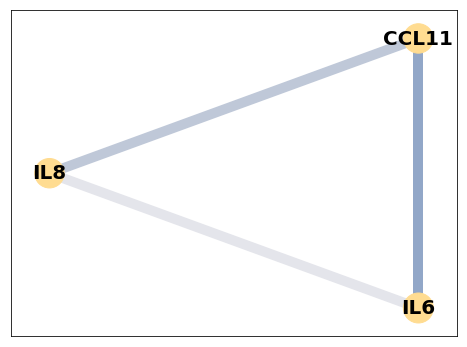

In [13]:
with rc_context({'figure.figsize': (8, 6)}):
    nx.draw_networkx(graph_0, pos = pos, width=10, node_size=size_l, node_color=node_colors, 
                     edge_color=weights, edge_cmap=cmap, edge_vmin=-1, edge_vmax=1,
                     font_weight='bold', font_size=20)

In [14]:
out_dir = r'.\cytokine_figures\edge_secretors\exp1_uc_014-1\networks'

In [15]:
graph = nx.Graph()
cmap = sns.color_palette('vlag', as_cmap=True)
for i in range(len(corr_l)):
    corr = corr_l[i]
    graph.clear()
    
    # Add nodes
    graph.add_nodes_from(corr.columns.tolist())
    
    # Add edges
    for item1 in corr.columns.tolist():
        for item2 in corr.columns.tolist():
            if not item1 == item2:
                graph.add_edge(item1, item2, weight=corr[item1][item2])
    
    # Position of node
    pos = nx.shell_layout(graph)
    
    # Size of nodes
    size_l = []
    for item in corr.columns.tolist():
        size_l.append(z_scores.iloc[i][item]*1000)
    
    # Node colors
    node_colors = []
    for item in corr.columns.tolist():
        if item=='CONA' or item=='WGA':
            node_colors.append('#925e99dd')
        else:
            node_colors.append('#ffdc91')
    
    # Edge colors
    edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
    
    with rc_context({'figure.figsize': (8,6)}):
        nx.draw_networkx(graph, pos = pos, width=10, node_size=size_l, node_color=node_colors, 
                         edge_color=weights, edge_cmap=cmap, edge_vmin=-1, edge_vmax=1,
                         font_weight='bold', font_size=20)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, r'exp1_uc_014-1_ring '+str(i)+'.png'))
    plt.clf()

<Figure size 576x432 with 0 Axes>